# LLM Fine-tuning + Eval — Resume → JSON (Colab / Kaggle T4)

Runs the full project on a **free T4**: install → build data → QLoRA fine-tune → base-vs-fine-tuned eval → view the comparison table.

**Before running:** set `Runtime → Change runtime type → GPU (T4)`.

The base model (`Qwen/Qwen2.5-3B-Instruct`) is open — no HF login or API key needed.

## 1. Get the code
Clone your repo, or upload the project folder. Edit `GITHUB_URL` to your fork.

In [2]:
import os

GITHUB_URL = "https://github.com/zeelshah1805/llm-finetune.git"  # <-- edit me
REPO_DIR = "/content/llm-finetune"

if not os.path.isdir(REPO_DIR):
    !git clone $GITHUB_URL $REPO_DIR
%cd $REPO_DIR
!ls

Cloning into '/content/llm-finetune'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 37 (delta 7), reused 33 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 91.84 KiB | 1.35 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/llm-finetune
data  merge_and_push.py  PLAN.md    requirements.txt  schema.py
eval  notebooks		 README.md  results	      train.py


## 2. Install dependencies
`bitsandbytes` is the 4-bit quantization backend (CUDA only).

In [3]:
!pip install -q -r requirements.txt
# bitsandbytes must match the runtime's CUDA/Triton; force latest to avoid
# "No module named 'triton.ops'" / missing cudaXXX.so on current Colab.
!pip install -q -U bitsandbytes
import torch, bitsandbytes
print('CUDA available:', torch.cuda.is_available(), '|',
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')
print('bitsandbytes', bitsandbytes.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 3. Build the dataset (deterministic)
The splits are already committed; this just confirms they regenerate identically. The **test split is frozen**.

In [4]:
!python data/build_dataset.py --n 400 --seed 42

wrote  320 -> /content/llm-finetune/data/train.jsonl
wrote   40 -> /content/llm-finetune/data/val.jsonl
wrote   40 -> /content/llm-finetune/data/test.jsonl

Example resume:
------------------------------------------------------------
Diya Brown | diya.163@hotmail.com | 11y exp | Skills: Airflow,Spark,Hugging Face,Redis,GCP,Kubernetes,Azure | Full Stack Developer@Razorpay(1y) Data Scientist@Helix Systems(2.5y) DevOps Engineer@Wipro(2.5y) Machine Learning Engineer@Zomato(5y) | B.Tech in Electronics-Anna University-2023
------------------------------------------------------------
Target JSON:
{
  "name": "Diya Brown",
  "email": "diya.163@hotmail.com",
  "phone": null,
  "total_years_experience": 11,
  "skills": [
    "Airflow",
    "Spark",
    "Hugging Face",
    "Redis",
    "GCP",
    "Kubernetes",
    "Azure"
  ],
  "education": [
    {
      "degree": "B.Tech in Electronics",
      "institution": "Anna University",
      "year": 2023
    }
  ],
  "work_experience": [
    {
      "ti

## 4. QLoRA fine-tune
4-bit base + LoRA adapter. ~10–20 min on a T4 for 2 epochs. Watch the train/eval loss gap for overfitting.
Saves the adapter to `adapters/qwen-resume/` and a loss curve to `assets/loss_curve.png`.

In [5]:
!python train.py --base Qwen/Qwen2.5-3B-Instruct --epochs 2

2026-06-23 17:44:04.917396: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
tokenizer_config.json: 7.30kB [00:00, 27.3MB/s]
vocab.json: 2.78MB [00:00, 44.2MB/s]
merges.txt: 1.67MB [00:00, 133MB/s]
tokenizer.json: 7.03MB [00:00, 179MB/s]
config.json: 100% 661/661 [00:00<00:00, 6.20MB/s]
model.safetensors.index.json: 35.6kB [00:00, 102MB/s]
model-00001-of-00002.safetensors:   0% 0.00/3.97G [00:00<?, ?B/s]
model-00001-of-00002.safetensors:   0% 20.3k/3.97G [00:00<43:10:17, 25.5kB/s]
model-00001-of-00002.safetensors:   7% 268M/3.97G [00:02<00:35, 105MB/s]     
model-00001-of-00002.safetensors:  10% 402M/3.97G [00:03<00:22, 157MB/s]
model-00001-of-00002.safetensors:  12% 469M/3.97G [00:05<00:44, 79.3MB/s]
model-00001-of-00002.safetensors:  23% 930M/3.

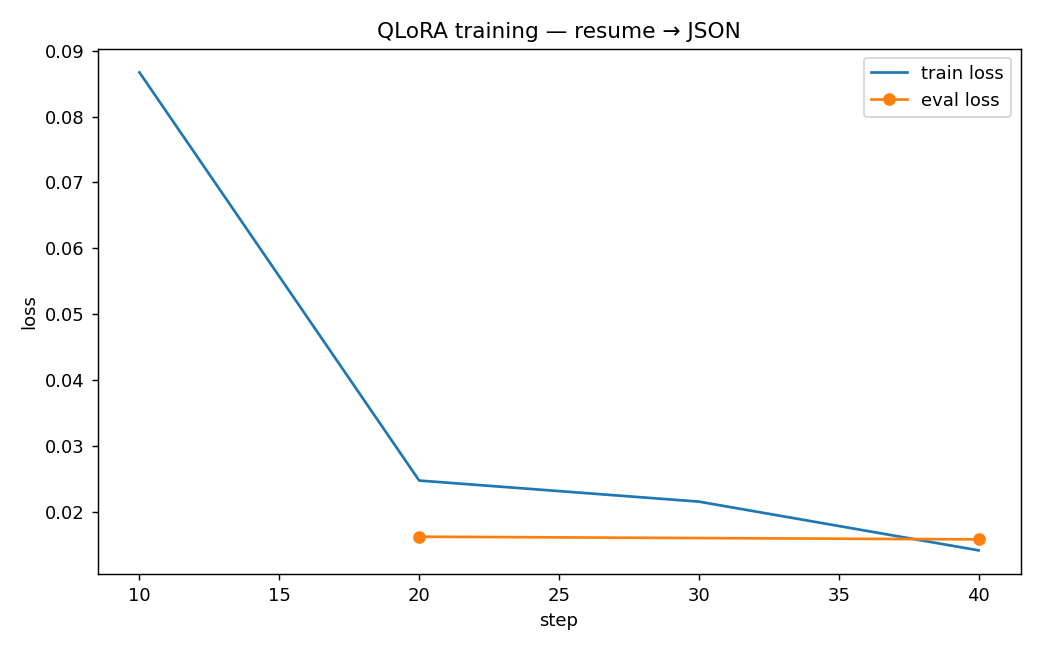

In [6]:
from IPython.display import Image
Image('assets/loss_curve.png')

## 5. Evaluate base vs. fine-tuned
Generates predictions for BOTH models on the same frozen test set, scores them, and writes `results/comparison.md` + charts.
Raw predictions are saved to `results/raw/` so you can re-score offline later without a GPU.

In [ ]:
!python eval/run_eval.py --base Qwen/Qwen2.5-3B-Instruct --adapter adapters/qwen-resume

[base] loading base=Qwen/Qwen2.5-3B-Instruct adapter=None 4bit=True
Loading checkpoint shards:   0% 0/2 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading checkpoint shards: 100% 2/2 [00:25<00:00, 12.59s/it]
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True

In [ ]:
from IPython.display import Markdown, Image, display
display(Markdown(open('results/comparison.md').read()))
display(Image('results/charts/headline.png'))
display(Image('results/charts/per_field_f1.png'))

## 6. (Optional) Merge + push to the Hugging Face Hub
Run `huggingface-cli login` first, then merge the adapter into fp16 weights and push with a model card.

In [ ]:
# from huggingface_hub import notebook_login; notebook_login()
# !python merge_and_push.py --adapter adapters/qwen-resume --push <your-username>/qwen2.5-3b-resume-json

## 7. Download artifacts
Pull the results back to your machine to commit them to the repo (the comparison table + charts are your strongest interview artifact).

In [ ]:
import shutil
shutil.make_archive('/content/artifacts', 'zip', '.', 'results')
shutil.make_archive('/content/adapter', 'zip', 'adapters', 'qwen-resume')
try:
    from google.colab import files
    files.download('/content/artifacts.zip')
    files.download('/content/adapter.zip')
except Exception as e:
    print('not on Colab or download unavailable:', e)